In [ ]:
##!pip install openpyxl

In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

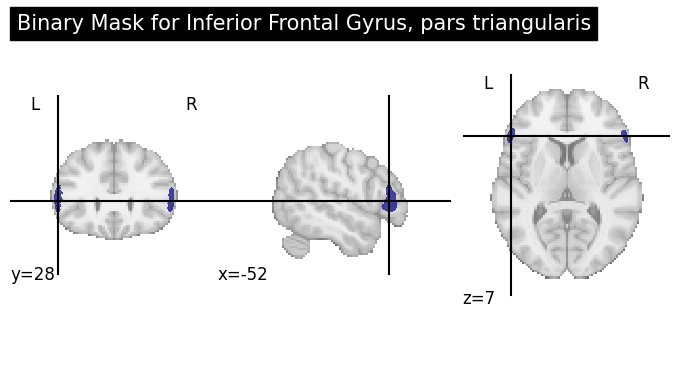

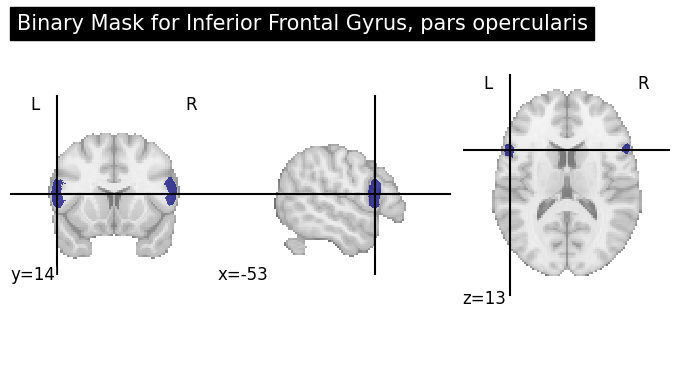

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Inferior Frontal Gyrus, pars triangularis"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis

# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)

# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Inferior Frontal Gyrus, pars opercularis"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()

## Loading a single ROI **(MEAN)**:- 1. Inferior Frontal Gyrus- pars triangularis
#### Then performing the experiments.

In [4]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
#print(control_mean_data1[79][2376])

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data1, non_dyslexic_mean_data1])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data1) + [0] * len(non_dyslexic_mean_data1))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(2377,)
(2377,)
(160, 2377)
(160,)


Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): 59.38%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Logistic Regression):
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): 0.59


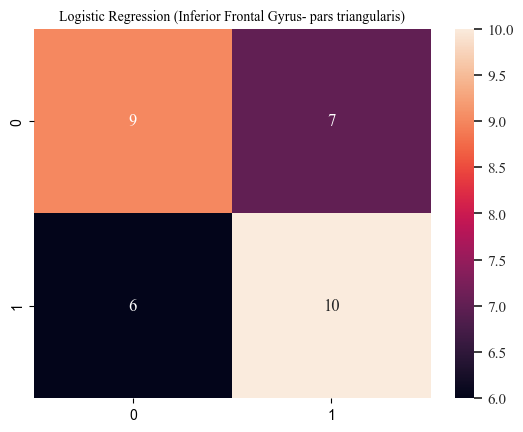

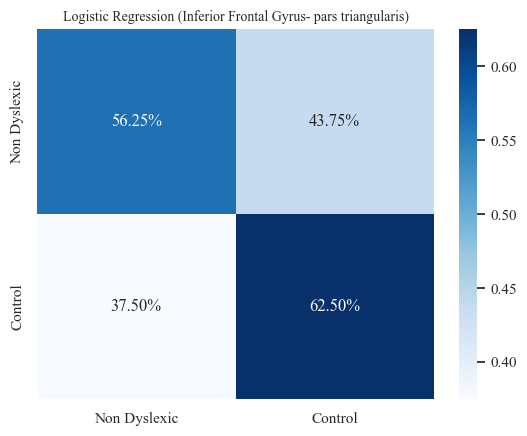

In [5]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): {log_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): {log_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Logistic Regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_ROI1[0][0]:.2f}, Precision 1:- {log_mean_prf_ROI1[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_ROI1[1][0]:.2f}, Recall 1:- {log_mean_prf_ROI1[1][1]:.2f}")
# print(f"f1-score 0:- {log_mean_prf_ROI1[2][0]:.2f}, f1-score 1:- {log_mean_prf_ROI1[2][1]:.2f}")
# print(f"Support 0:- {log_mean_prf_ROI1[3][0]}, Support 1:- {log_mean_prf_ROI1[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): {log_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Logistic Regression (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(Log_Reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic Regression (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(Log_Reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): 73.44%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): 65.62%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.65      0.69      0.67        16
           1       0.67      0.62      0.65        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.66        32
weighted avg       0.66      0.66      0.66        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): 0.66


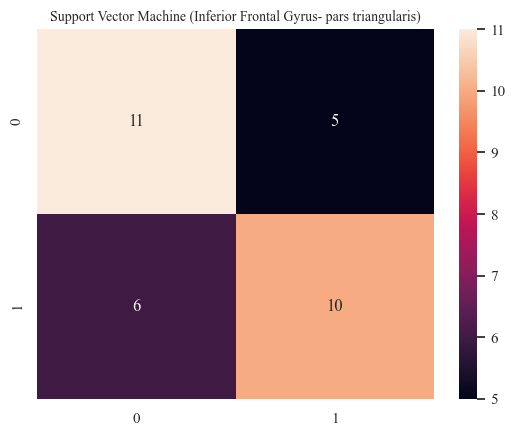

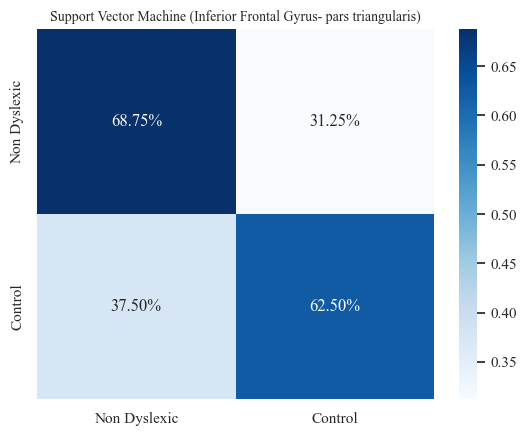

In [6]:
###### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Calculate training and testing accuracy
svm_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): {svm_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): {svm_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {svm_mean_prf_ROI1[0][0]:.2f}, Precision 1:- {svm_mean_prf_ROI1[0][1]:.2f}")
# print(f"Recall 0:- {svm_mean_prf_ROI1[1][0]:.2f}, Recall 1:- {svm_mean_prf_ROI1[1][1]:.2f}")
# print(f"f1-score 0:- {svm_mean_prf_ROI1[2][0]:.2f}, f1-score 1:- {svm_mean_prf_ROI1[2][1]:.2f}")
# print(f"Support 0:- {svm_mean_prf_ROI1[3][0]}, Support 1:- {svm_mean_prf_ROI1[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): {svm_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): 69.53%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): 56.25%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.55      0.75      0.63        16
           1       0.60      0.38      0.46        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.55        32
weighted avg       0.57      0.56      0.55        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): 0.56


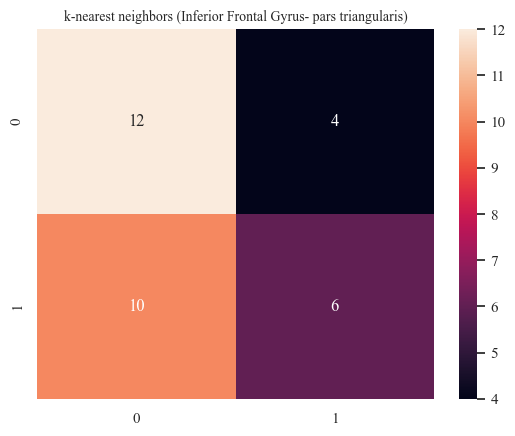

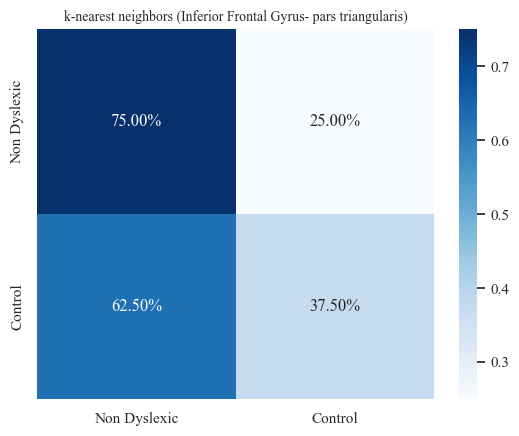

In [7]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): {knn_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): {knn_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {knn_mean_prf_ROI1[0][0]:.2f}, Precision 1:- {knn_mean_prf_ROI1[0][1]:.2f}")
# print(f"Recall 0:- {knn_mean_prf_ROI1[1][0]:.2f}, Recall 1:- {knn_mean_prf_ROI1[1][1]:.2f}")
# print(f"f1-score 0:- {knn_mean_prf_ROI1[2][0]:.2f}, f1-score 1:- {knn_mean_prf_ROI1[2][1]:.2f}")
# print(f"Support 0:- {knn_mean_prf_ROI1[3][0]}, Support 1:- {knn_mean_prf_ROI1[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): {knn_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(KNN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Random Forest): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Random Forest): 59.38%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Random Forest):
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Random Forest): 0.59


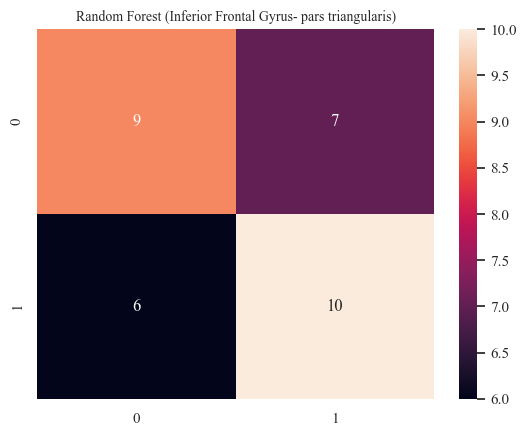

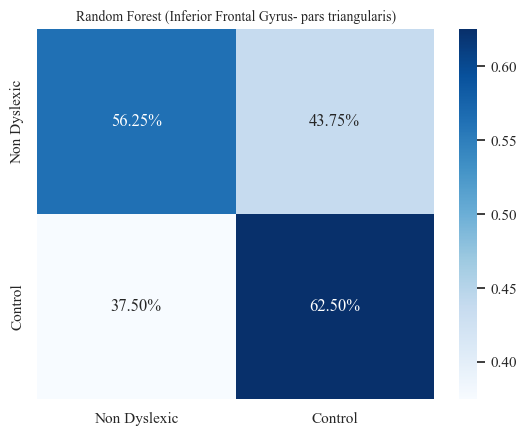

In [8]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Random Forest): {rf_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Random Forest): {rf_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Random Forest): {rf_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Random Forest (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(Rand_Forst)_percent.png", dpi=600)
plt.show()

In [ ]:
!pip install xgboost

Training Accuracy on Inferior Frontal Gyrus- pars triangularis (XGBoost): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (XGBoost): 78.12%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (XGBoost):
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        16
           1       0.76      0.81      0.79        16

    accuracy                           0.78        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.78      0.78      0.78        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (XGBoost): 0.78


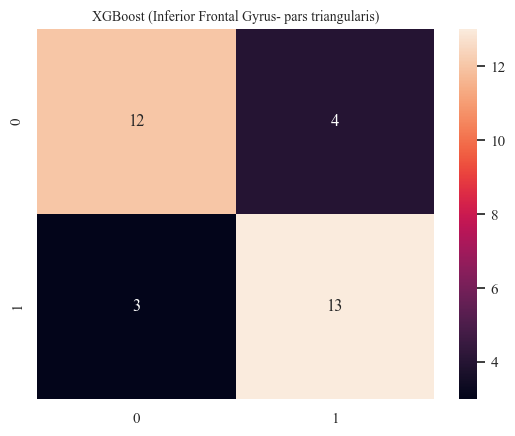

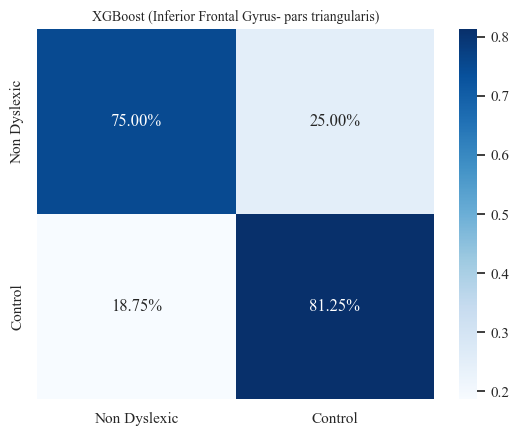

In [9]:
import xgboost as xgb
##### XGBoost (eXtreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (XGBoost): {xgb_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (XGBoost): {xgb_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (XGBoost): {xgb_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('XGBoost (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(XGBst)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 2377) Label:- (128,)
Total Testing set:-  Dataset:- (32, 2377) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         304,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 314,753 (1.20 MB)

 Trainable params: 314,753 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5104 - loss: 1.1301
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7292 - loss: 0.4984
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8125 - loss: 0.4142
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8542 - loss: 0.3683
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9271 - loss: 0.3538
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9583 - loss: 0.3276
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9427 - loss: 0.3279
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9792 - loss: 0.2848
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9948 - loss: 0.2618
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9896 - loss: 0.2497
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9896 - loss: 0.2189
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9896 - loss: 0.1938
E

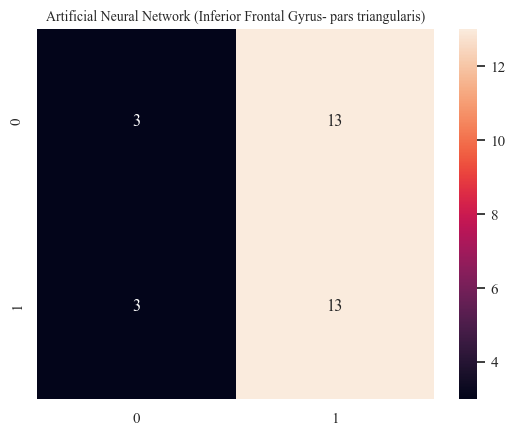

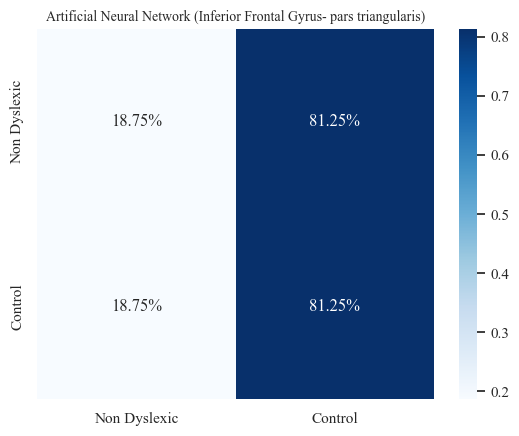

In [10]:
###### ANN Model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network): {ann_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network): {ann_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {ann_mean_prf_ROI1[0][0]:.2f}, Precision 1:- {ann_mean_prf_ROI1[0][1]:.2f}")
# print(f"Recall 0:- {ann_mean_prf_ROI1[1][0]:.2f}, Recall 1:- {ann_mean_prf_ROI1[1][1]:.2f}")
# print(f"f1-score 0:- {ann_mean_prf_ROI1[2][0]:.2f}, f1-score 1:- {ann_mean_prf_ROI1[2][1]:.2f}")
# print(f"Support 0:- {ann_mean_prf_ROI1[3][0]}, Support 1:- {ann_mean_prf_ROI1[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network): {ann_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_1(ANN)_percent.png", dpi=600)
plt.show()

In [7]:
# mean1=[]
# mean1.append([log_mean_prf_ROI1[0][0],log_mean_prf_ROI1[1][0],log_mean_prf_ROI1[2][0],log_mean_test_accuracy_ROI1,log_mean_roc_ROI1])
# mean1.append([log_mean_prf_ROI1[0][1],log_mean_prf_ROI1[1][1],log_mean_prf_ROI1[2][1],'',''])
# mean1.append([svm_mean_prf_ROI1[0][0],svm_mean_prf_ROI1[1][0],svm_mean_prf_ROI1[2][0],svm_mean_test_accuracy_ROI1,svm_mean_roc_ROI1])
# mean1.append([svm_mean_prf_ROI1[0][1],svm_mean_prf_ROI1[1][1],svm_mean_prf_ROI1[2][1],'',''])
# mean1.append([knn_mean_prf_ROI1[0][0],knn_mean_prf_ROI1[1][0],knn_mean_prf_ROI1[2][0],knn_mean_test_accuracy_ROI1,knn_mean_roc_ROI1])
# mean1.append([knn_mean_prf_ROI1[0][1],knn_mean_prf_ROI1[1][1],knn_mean_prf_ROI1[2][1],'',''])
# mean1.append([ann_mean_prf_ROI1[0][0],ann_mean_prf_ROI1[1][0],ann_mean_prf_ROI1[2][0],ann_mean_test_accuracy_ROI1,ann_mean_roc_ROI1])
# mean1.append([ann_mean_prf_ROI1[0][1],ann_mean_prf_ROI1[1][1],ann_mean_prf_ROI1[2][1],'',''])

In [11]:
mean1=[]
mean1.append([round(log_mean_prf_ROI1[0][0],2),round(log_mean_prf_ROI1[1][0],2),round(log_mean_prf_ROI1[2][0],2),round(log_mean_test_accuracy_ROI1,2),round(log_mean_roc_ROI1,2)])
mean1.append([round(log_mean_prf_ROI1[0][1],2),round(log_mean_prf_ROI1[1][1],2),round(log_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(svm_mean_prf_ROI1[0][0],2),round(svm_mean_prf_ROI1[1][0],2),round(svm_mean_prf_ROI1[2][0],2),round(svm_mean_test_accuracy_ROI1,2),round(svm_mean_roc_ROI1,2)])
mean1.append([round(svm_mean_prf_ROI1[0][1],2),round(svm_mean_prf_ROI1[1][1],2),round(svm_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(knn_mean_prf_ROI1[0][0],2),round(knn_mean_prf_ROI1[1][0],2),round(knn_mean_prf_ROI1[2][0],2),round(knn_mean_test_accuracy_ROI1,2),round(knn_mean_roc_ROI1,2)])
mean1.append([round(knn_mean_prf_ROI1[0][1],2),round(knn_mean_prf_ROI1[1][1],2),round(knn_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(ann_mean_prf_ROI1[0][0],2),round(ann_mean_prf_ROI1[1][0],2),round(ann_mean_prf_ROI1[2][0],2),round(ann_mean_test_accuracy_ROI1,2),round(ann_mean_roc_ROI1,2)])
mean1.append([round(ann_mean_prf_ROI1[0][1],2),round(ann_mean_prf_ROI1[1][1],2),round(ann_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(rf_mean_prf_ROI1[0][0],2),round(rf_mean_prf_ROI1[1][0],2),round(rf_mean_prf_ROI1[2][0],2),round(rf_mean_test_accuracy_ROI1,2),round(rf_mean_roc_ROI1,2)])
mean1.append([round(rf_mean_prf_ROI1[0][1],2),round(rf_mean_prf_ROI1[1][1],2),round(rf_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(xgb_mean_prf_ROI1[0][0],2),round(xgb_mean_prf_ROI1[1][0],2),round(xgb_mean_prf_ROI1[2][0],2),round(xgb_mean_test_accuracy_ROI1,2),round(xgb_mean_roc_ROI1,2)])
mean1.append([round(xgb_mean_prf_ROI1[0][1],2),round(xgb_mean_prf_ROI1[1][1],2),round(xgb_mean_prf_ROI1[2][1],2),'',''])

df1 = pd.DataFrame(mean1,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df=df.style.set_sticky(axis="index")
df1=df1.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
display(df1)
df1.to_excel('../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Table_Mean_ROI_1_Inferior_Frontal_Gyrus.xlsx', engine='openpyxl')


## Loading a single ROI **(MEAN)**:- 2. Inferior Frontal Gyrus- pars opercularis
#### Then performing the experiments.

In [12]:
####Loading the saved dataset in np format.
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data2, non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data2) + [0] * len(non_dyslexic_mean_data2))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(3846,)
(3846,)
(160, 3846)
(160,)


Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): 43.75%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Logistic regression):
              precision    recall  f1-score   support

           0       0.40      0.25      0.31        16
           1       0.45      0.62      0.53        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.42        32
weighted avg       0.43      0.44      0.42        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Logistic Regression): 0.44


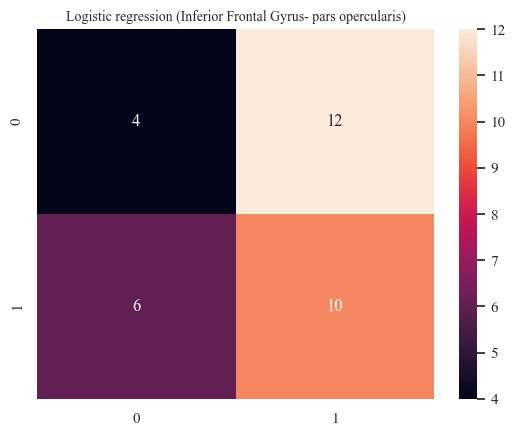

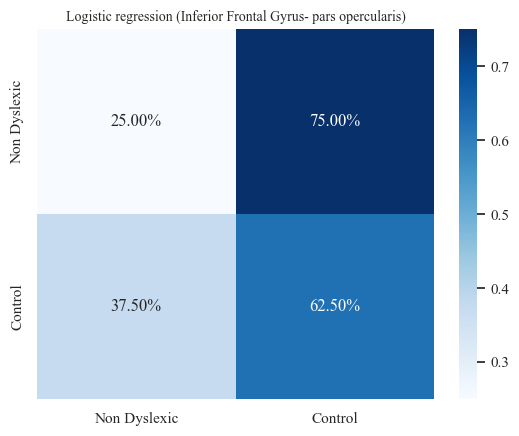

In [13]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): {log_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): {log_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_ROI2[0][0]:.2f}, Precision 1:- {log_mean_prf_ROI2[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_ROI2[1][0]:.2f}, Recall 1:- {log_mean_prf_ROI2[1][1]:.2f}")
# print(f"f1-score 0:- {log_mean_prf_ROI2[2][0]:.2f}, f1-score 1:- {log_mean_prf_ROI2[2][1]:.2f}")
# print(f"Support 0:- {log_mean_prf_ROI2[3][0]}, Support 1:- {log_mean_prf_ROI2[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Logistic Regression): {log_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): 73.44%
Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): 65.62%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.63      0.75      0.69        16
           1       0.69      0.56      0.62        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.65        32
weighted avg       0.66      0.66      0.65        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): 0.66


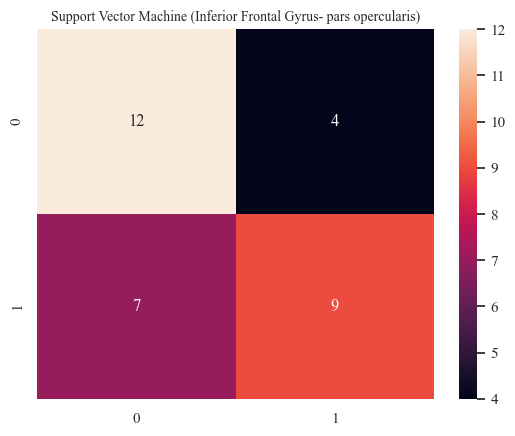

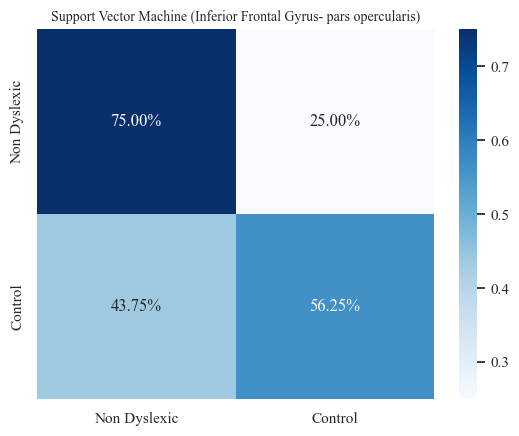

In [14]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): {svm_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): {svm_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {svm_mean_prf_ROI2[0][0]:.2f}, Precision 1:- {svm_mean_prf_ROI2[0][1]:.2f}")
# print(f"Recall 0:- {svm_mean_prf_ROI2[1][0]:.2f}, Recall 1:- {svm_mean_prf_ROI2[1][1]:.2f}")
# print(f"f1-score 0:- {svm_mean_prf_ROI2[2][0]:.2f}, f1-score 1:- {svm_mean_prf_ROI2[2][1]:.2f}")
# print(f"Support 0:- {svm_mean_prf_ROI2[3][0]}, Support 1:- {svm_mean_prf_ROI2[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): {svm_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): 54.69%
Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): 46.88%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.48      0.94      0.64        16

    accuracy                           0.47        32
   macro avg       0.24      0.47      0.32        32
weighted avg       0.24      0.47      0.32        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): 0.47


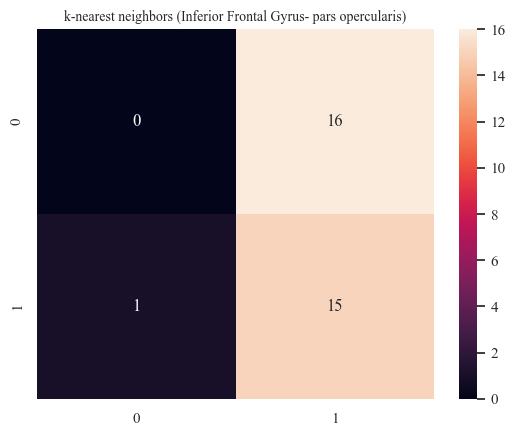

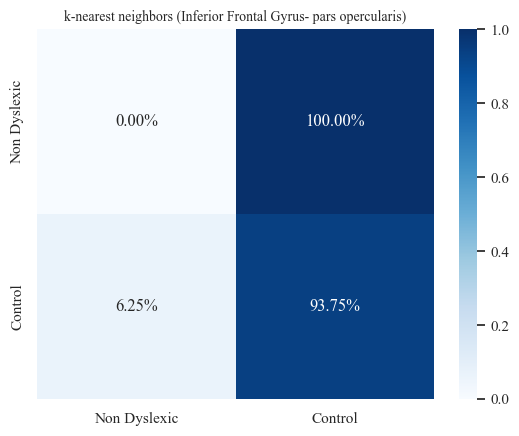

In [15]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): {knn_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): {knn_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {knn_mean_prf_ROI2[0][0]:.2f}, Precision 1:- {knn_mean_prf_ROI2[0][1]:.2f}")
# print(f"Recall 0:- {knn_mean_prf_ROI2[1][0]:.2f}, Recall 1:- {knn_mean_prf_ROI2[1][1]:.2f}")
# print(f"f1-score 0:- {knn_mean_prf_ROI2[2][0]:.2f}, f1-score 1:- {knn_mean_prf_ROI2[2][1]:.2f}")
# print(f"Support 0:- {knn_mean_prf_ROI2[3][0]}, Support 1:- {knn_mean_prf_ROI2[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): {knn_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 3846) Label:- (128,)
Total Testing set:-  Dataset:- (32, 3846) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │         492,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 502,785 (1.92 MB)

 Trainable params: 502,785 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4688 - loss: 0.8240 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7604 - loss: 0.4286
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9271 - loss: 0.3717
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9740 - loss: 0.3439
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9844 - loss: 0.2950
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9896 - loss: 0.2687
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.2384
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2005
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.1502
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1188
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0844
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0583


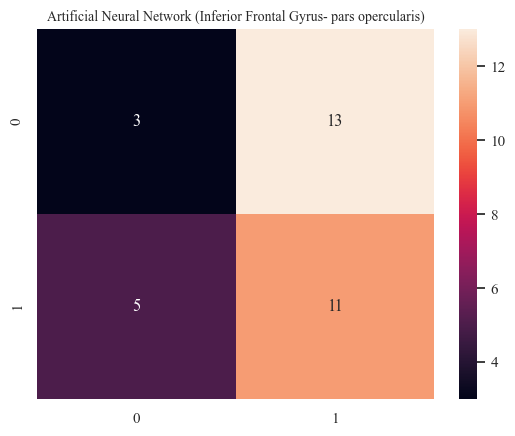

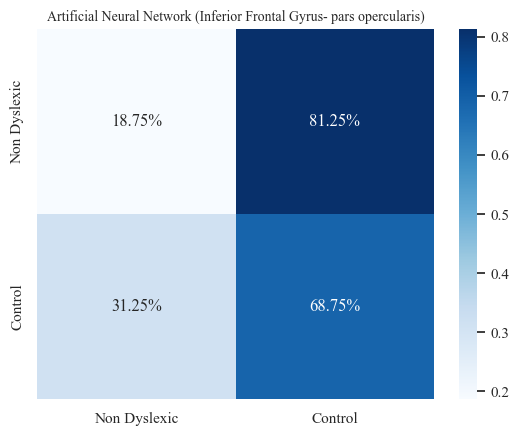

In [16]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network): {ann_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network): {ann_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {ann_mean_prf_ROI2[0][0]:.2f}, Precision 1:- {ann_mean_prf_ROI2[0][1]:.2f}")
# print(f"Recall 0:- {ann_mean_prf_ROI2[1][0]:.2f}, Recall 1:- {ann_mean_prf_ROI2[1][1]:.2f}")
# print(f"f1-score 0:- {ann_mean_prf_ROI2[2][0]:.2f}, f1-score 1:- {ann_mean_prf_ROI2[2][1]:.2f}")
# print(f"Support 0:- {ann_mean_prf_ROI2[3][0]}, Support 1:- {ann_mean_prf_ROI2[3][1]}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network): {ann_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Random Forest): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Random Forest): 59.38%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Random Forest):
              precision    recall  f1-score   support

           0       0.64      0.44      0.52        16
           1       0.57      0.75      0.65        16

    accuracy                           0.59        32
   macro avg       0.60      0.59      0.58        32
weighted avg       0.60      0.59      0.58        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Random Forest): 0.59


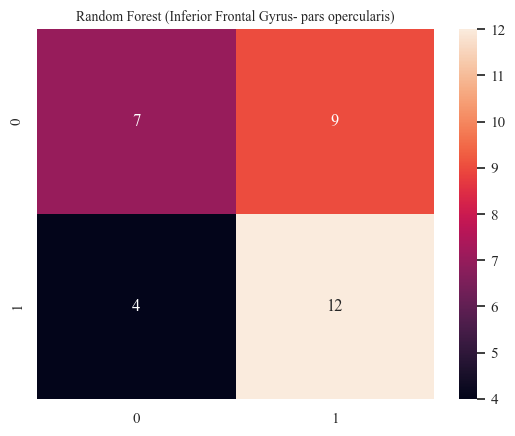

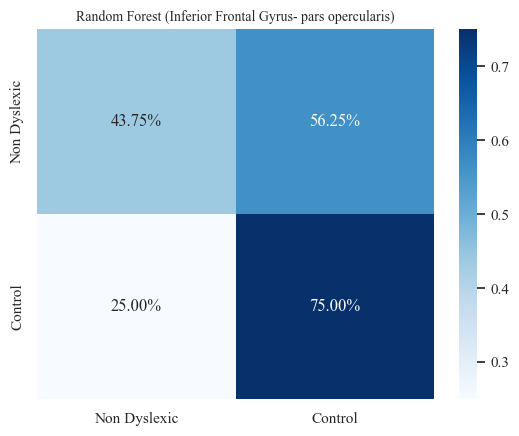

In [17]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Random Forest): {rf_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Random Forest): {rf_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (Random Forest): {rf_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars opercularis (XGBoost): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (XGBoost): 59.38%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (XGBoost):
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (XGBoost): 0.59


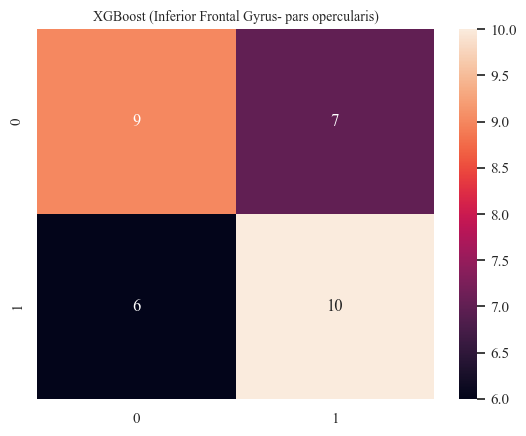

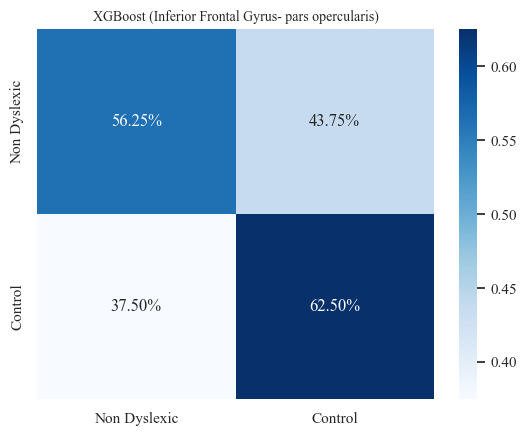

In [19]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (XGBoost): {xgb_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (XGBoost): {xgb_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars opercularis (XGBoost): {xgb_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_ROI_2(XGBst)_percent.png", dpi=600)
plt.show()

In [20]:
mean2=[]
mean2.append([round(log_mean_prf_ROI2[0][0],2),round(log_mean_prf_ROI2[1][0],2),round(log_mean_prf_ROI2[2][0],2),round(log_mean_test_accuracy_ROI2,2),round(log_mean_roc_ROI2,2)])
mean2.append([round(log_mean_prf_ROI2[0][1],2),round(log_mean_prf_ROI2[1][1],2),round(log_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(svm_mean_prf_ROI2[0][0],2),round(svm_mean_prf_ROI2[1][0],2),round(svm_mean_prf_ROI2[2][0],2),round(svm_mean_test_accuracy_ROI2,2),round(svm_mean_roc_ROI2,2)])
mean2.append([round(svm_mean_prf_ROI2[0][1],2),round(svm_mean_prf_ROI2[1][1],2),round(svm_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(knn_mean_prf_ROI2[0][0],2),round(knn_mean_prf_ROI2[1][0],2),round(knn_mean_prf_ROI2[2][0],2),round(knn_mean_test_accuracy_ROI2,2),round(knn_mean_roc_ROI2,2)])
mean2.append([round(knn_mean_prf_ROI2[0][1],2),round(knn_mean_prf_ROI2[1][1],2),round(knn_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(ann_mean_prf_ROI2[0][0],2),round(ann_mean_prf_ROI2[1][0],2),round(ann_mean_prf_ROI2[2][0],2),round(ann_mean_test_accuracy_ROI2,2),round(ann_mean_roc_ROI2,2)])
mean2.append([round(ann_mean_prf_ROI2[0][1],2),round(ann_mean_prf_ROI2[1][1],2),round(ann_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(rf_mean_prf_ROI2[0][0],2),round(rf_mean_prf_ROI2[1][0],2),round(rf_mean_prf_ROI2[2][0],2),round(rf_mean_test_accuracy_ROI2,2),round(rf_mean_roc_ROI2,2)])
mean2.append([round(rf_mean_prf_ROI2[0][1],2),round(rf_mean_prf_ROI2[1][1],2),round(rf_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(xgb_mean_prf_ROI2[0][0],2),round(xgb_mean_prf_ROI2[1][0],2),round(xgb_mean_prf_ROI2[2][0],2),round(xgb_mean_test_accuracy_ROI2,2),round(xgb_mean_roc_ROI2,2)])
mean2.append([round(xgb_mean_prf_ROI2[0][1],2),round(xgb_mean_prf_ROI2[1][1],2),round(xgb_mean_prf_ROI2[2][1],2),'',''])

df2 = pd.DataFrame(mean2,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_2 (Mean) Inferior Frontal Gyrus- pars opercularis")
display(df2)
df2.to_excel('../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Table_Mean_ROI_2_Inferior_Frontal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.40    0.25      0.31     0.44   
                           Control            0.45    0.62      0.53            
Support Vector Machine     Non-Dyslexic       0.63    0.75      0.69     0.66   
                           Control            0.69    0.56      0.62            
k-nearest neighbors        Non-Dyslexic       0.00    0.00      0.00     0.47   
                           Control            0.48    0.94      0.64            
Artificial Neural Networks Non-Dyslexic       0.38    0.19      0.25     0.44   
                           Control            0.46    0.69      0.55            
Random Forest              Non-Dyslexic       0.64    0.44      0.52     0.59   
                           Control            0.57    0.75      0.65            
XGBoost                    Non-Dyslexic       0.60    0.56      0.58     0.59   
                           Control            0.59    0.62      0.61            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.44  
                           Control               
Support Vector Machine     Non-Dyslexic    0.66  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.47  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.44  
                           Control               
Random Forest              Non-Dyslexic    0.59  
                           Control               
XGBoost                    Non-Dyslexic    0.59  
                           Control

## Combining all the ROIs **(MEAN)**:- Inferior Frontal Gyrus- 1) pars triangularis & 2) pars opercularis.
#### Combining them into a single dataset to perform the experiments.

In [21]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    #control_mean_data1[i]=np.resize(control_mean_data1[i], (control_mean_data2[0].shape[0], ))
    #control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'constant'))
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
    #control_m_d1.insert(i, np.resize(control_mean_data1[i], (control_mean_data2[0].shape[0], )))
for i in range(len(non_dyslexic_mean_data1)):
    #non_dyslexic_mean_data1[i]=np.resize(non_dyslexic_mean_data1[i], (non_dyslexic_mean_data2[0].shape[0], ))
    #non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'constant'))
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
    #non_dyslexic_m_d1.insert(i, np.resize(non_dyslexic_mean_data1[i], (non_dyslexic_mean_data2[0].shape[0], )))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)


80
80
80
80
(2377,)
(2377,)
(3846,)
(3846,)

(3846,)
(3846,)
(3846,)
(3846,)


In [22]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2, non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(320, 3846)
(320,)


Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): 50.00%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression):
              precision    recall  f1-score   support

           0       0.50      0.47      0.48        32
           1       0.50      0.53      0.52        32

    accuracy                           0.50        64
   macro avg       0.50      0.50      0.50        64
weighted avg       0.50      0.50      0.50        64


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic Regression): 0.50


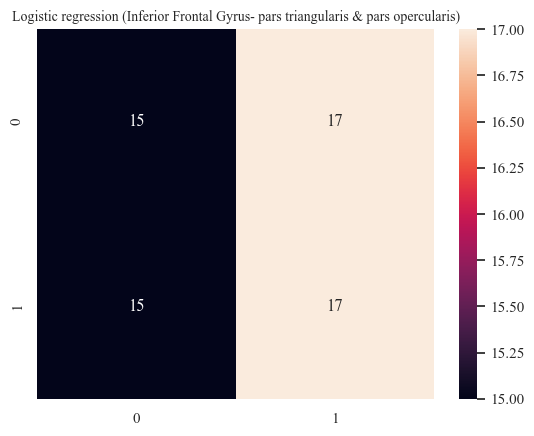

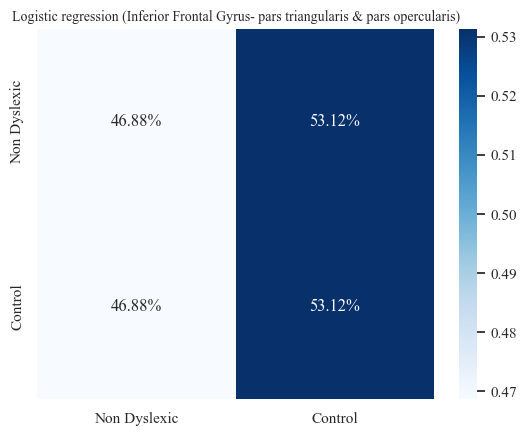

In [23]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): 74.61%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): 53.12%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.52      0.72      0.61        32
           1       0.55      0.34      0.42        32

    accuracy                           0.53        64
   macro avg       0.54      0.53      0.51        64
weighted avg       0.54      0.53      0.51        64


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): 0.53


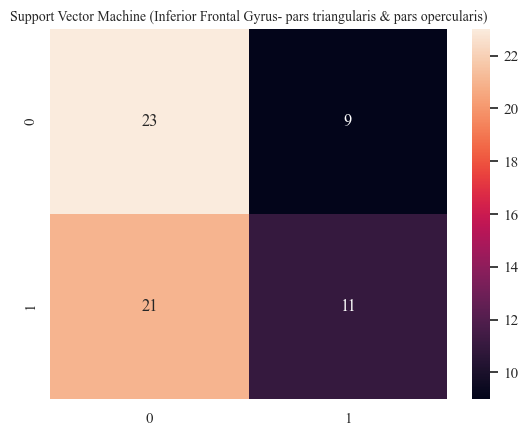

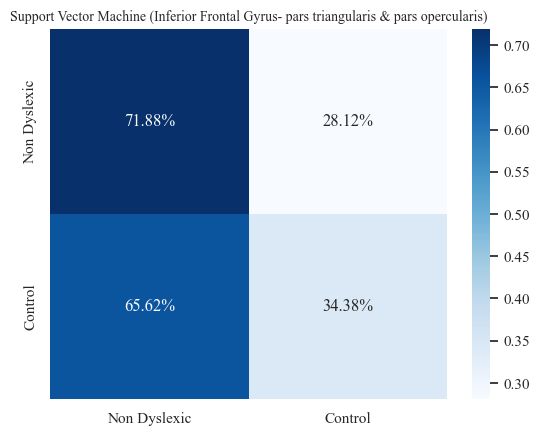

In [24]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): 59.77%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): 45.31%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.38      0.16      0.22        32
           1       0.47      0.75      0.58        32

    accuracy                           0.45        64
   macro avg       0.43      0.45      0.40        64
weighted avg       0.43      0.45      0.40        64


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): 0.45


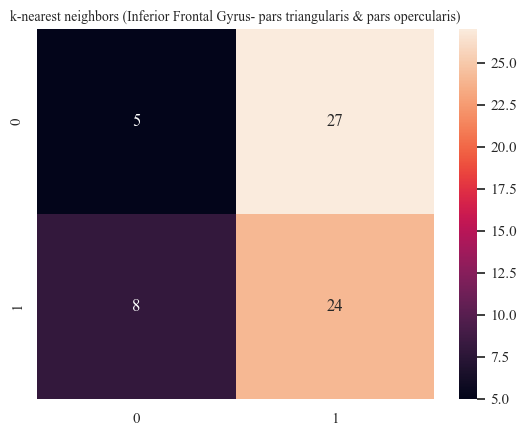

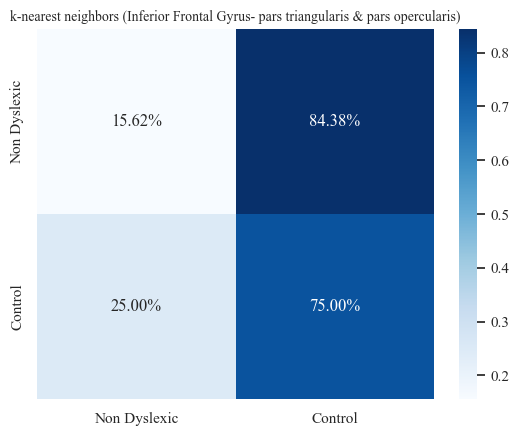

In [25]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(KNN)_percent.png", dpi=600)
plt.show()

In [26]:

ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2, non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
# yyyy = np.array([1] * ll1 + [0] * ll2)  # Binary labels
# y=np.zeros((yyyy.size, yyyy.max() + 1))
# y[np.arange(yyyy.size), yyyy] = 1
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (320, 3846)
Total Labels:-  (320,)
Total Training set:-  Dataset:- (256, 3846) Label:- (256,)
Total Testing set:-  Dataset:- (64, 3846) Label:- (64,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │         492,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 502,785 (1.92 MB)

 Trainable params: 502,785 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4922 - loss: 0.7538 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8229 - loss: 0.4556
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8802 - loss: 0.3780 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9328 - loss: 0.3234
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9510 - loss: 0.2838
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9818 - loss: 0.2343 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9885 - loss: 0.1879
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9911 - loss: 0.1289
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9885 - loss: 0.0801
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9958 - loss: 0.0373
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0250
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0188


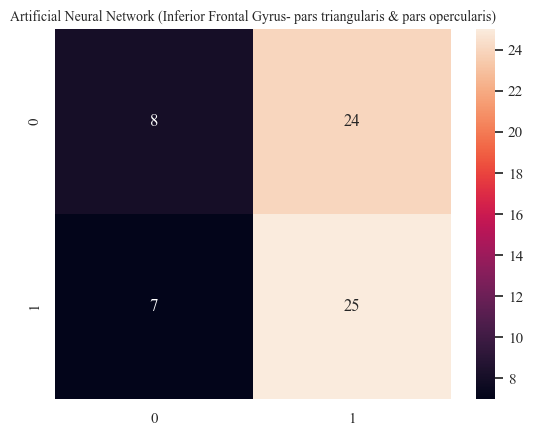

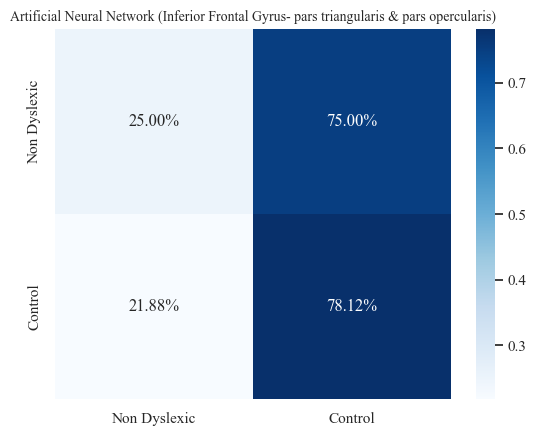

In [27]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): 57.81%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest):
              precision    recall  f1-score   support

           0       0.58      0.56      0.57        32
           1       0.58      0.59      0.58        32

    accuracy                           0.58        64
   macro avg       0.58      0.58      0.58        64
weighted avg       0.58      0.58      0.58        64


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): 0.58


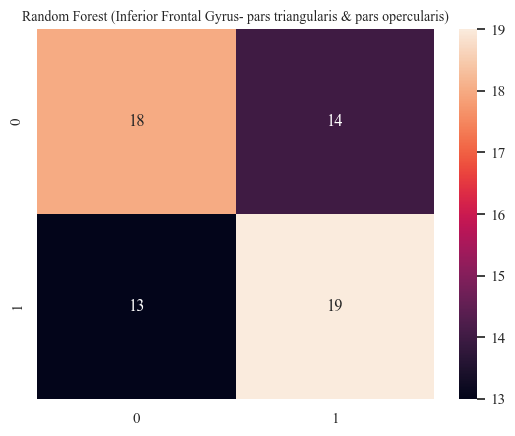

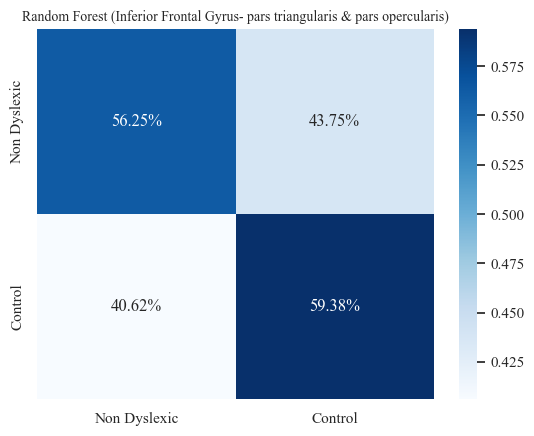

In [28]:
# Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): 100.00%
Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): 45.31%

Classification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost):
              precision    recall  f1-score   support

           0       0.45      0.41      0.43        32
           1       0.46      0.50      0.48        32

    accuracy                           0.45        64
   macro avg       0.45      0.45      0.45        64
weighted avg       0.45      0.45      0.45        64


ROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): 0.45


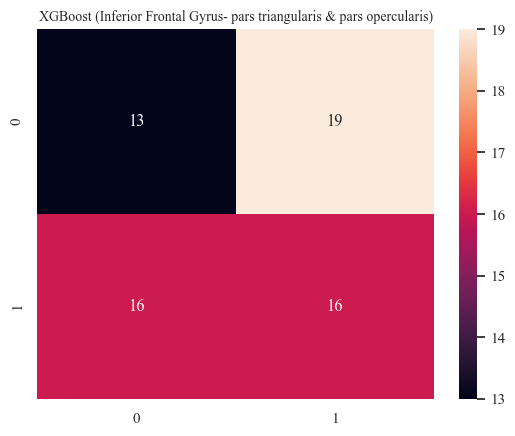

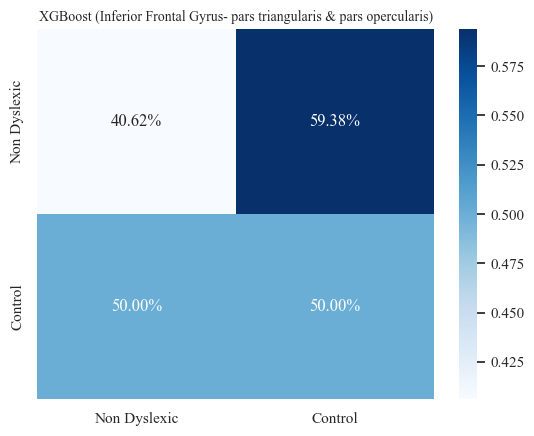

In [30]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Inferior_Frontal_Gyrus_All_ROIs(XGBst)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [31]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Inferior Frontal Gyrus- pars opercularis & pars opercularis [All ROIs (Mean)]")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/1-Inferior_Frontal_Gyrus/Output_Mean/Table_Mean_All_ROIs_Inferior_Frontal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.50    0.47      0.48      0.5   
                           Control            0.50    0.53      0.52            
Support Vector Machine     Non-Dyslexic       0.52    0.72      0.61     0.53   
                           Control            0.55    0.34      0.42            
k-nearest neighbors        Non-Dyslexic       0.38    0.16      0.22     0.45   
                           Control            0.47    0.75      0.58            
Artificial Neural Networks Non-Dyslexic       0.53    0.25      0.34     0.52   
                           Control            0.51    0.78      0.62            
Random Forest              Non-Dyslexic       0.58    0.56      0.57     0.58   
                           Control            0.58    0.59      0.58            
XGBoost                    Non-Dyslexic       0.45    0.41      0.43     0.45   
                           Control            0.46    0.50      0.48            

                                        roc_auc  
Logistic Regression        Non-Dyslexic     0.5  
                           Control               
Support Vector Machine     Non-Dyslexic    0.53  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.45  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.52  
                           Control               
Random Forest              Non-Dyslexic    0.58  
                           Control               
XGBoost                    Non-Dyslexic    0.45  
                           Control